<a href="https://colab.research.google.com/github/dixitkumar10101988-alt/Full-Stack-GenAI-Bootcamp-1.0/blob/main/foodhub_order.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#FoodHub Marketplace Exploratory Data Analysis & Operations Notebook
A unified, submission-grade Python notebook delivering rigorous descriptive
statistics, univariate & multivariate distributions, quality operational visualizations,
and strategic market recommendations.

Author: Dixit

Dataset: FoodHub Orders Analysis


### import  packages

In [1]:

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure publication-grade styling for inline Google Colab presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,

    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (12, 6),
    'patch.edgecolor': 'none'
})

# 1. Understanding the structure of the data


In [2]:


DATA_PATH = 'foodhub_order.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"CRITICAL ERROR: '{DATA_PATH}' not detected in working workspace. "
        "Please drag and drop your data file directly into the Colab left sidebar folder panel."
    )

print("=" * 100)
print("SECTION 1: STRUCTURAL COMPOSITION, DATATYPES & SYSTEM DATA QUALITY AUDIT")
print("=" * 100)

# Ingest master file
df = pd.read_csv(DATA_PATH)

# Structural dimensions profiling
rows, cols = df.shape
missing_cells = df.isna().sum().sum()
primary_duplicates = df['order_id'].duplicated().sum()
unique_customers = df['customer_id'].nunique()
unique_restaurants = df['restaurant_name'].nunique()

print(f"• Dataset Row Metric Count        : {rows}")
print(f"• Dataset Column Metric Count     : {cols}")
print(f"• Absolute Null / Missing Elements: {missing_cells}")
print(f"• Primary Key Duplicates Found    : {primary_duplicates}")
print(f"• Active Marketplace Customers    : {unique_customers}")
print(f"• Distinct Active Restaurants     : {unique_restaurants}")
print("\n" + "-" * 60 + "\n• Core Feature Type Index Matrix:")
print(df.info())

print("\n" + "-" * 60 + "\n• Descriptive Numeric Statistics Table Summary:")
print(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].describe().T)
print("=" * 100 + "\n")

SECTION 1: STRUCTURAL COMPOSITION, DATATYPES & SYSTEM DATA QUALITY AUDIT
• Dataset Row Metric Count        : 1898
• Dataset Column Metric Count     : 9
• Absolute Null / Missing Elements: 0
• Primary Key Duplicates Found    : 0
• Active Marketplace Customers    : 1200
• Distinct Active Restaurants     : 178

------------------------------------------------------------
• Core Feature Type Index Matrix:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation

#1. Structural Scale & Complete Data Integrity
Zero-Loss Quality Baseline: The platform tracks 1,898 unique orders across 9 core operational features. The absolute count of 0 missing or null elements combined with 0 duplicate primary keys (order_id) ensures a highly reliable data foundation for modeling, forecasting, and reporting.

Network Footprint: The platform acts as a decentralized marketplace supporting a structural ratio of 1200 active customers buying from 178 distinct restaurants. This reveals a healthy breadth of supply, indicating no single dominant restaurant bottleneck is skewing the system metrics.

#2. Financial Dynamics & Cart Scaling
Average Ticket Baseline: The mean gross cart value sits at $16.50, but the median (50%) value rests at $14.14. This gap confirms a moderate right-skewed distribution, driven by smaller individual meals.

The Upper Tier Hook: The 75th percentile sits at $22.30, trailing up to a maximum single order cost of $35.41. Because a significant portion of orders naturally sit just past the $20 line, there is an established user base already placing higher-margin premium multi-person orders.

#3. Operational Turnaround & Logistical Stability
Predictable Kitchen Latency: Kitchen processing (food_preparation_time) is tightly bounded between 20 and 35 minutes, maintaining an incredibly clean standard deviation of 4.63 minutes and a mean of 27.37 minutes. Restaurants operate on standardized prep structures that scale predictably regardless of cooking volume.

Logistical Variability: Courier transit times (delivery_time) present a broader operational range relative to their scale, spanning from a fast 15 minutes to a maximum travel window of 33 minutes. This indicates that external factors (e.g., day-of-week traffic grids or delivery zone distances) inject more variance into the overall timeline than the kitchens themselves.

#2. Univariate Data Analysis


In [3]:
# =============================================================================
# SECTION II: UNIVARIATE DATA EXPLORATION & DISTRIBUTIONS
# =============================================================================
print("=" * 100)
print("SECTION 2: PHASE I UNIVARIATE ANALYSIS - SYSTEM METRICS DISTRIBUTIONS")
print("=" * 100)

SECTION 2: PHASE I UNIVARIATE ANALYSIS - SYSTEM METRICS DISTRIBUTIONS


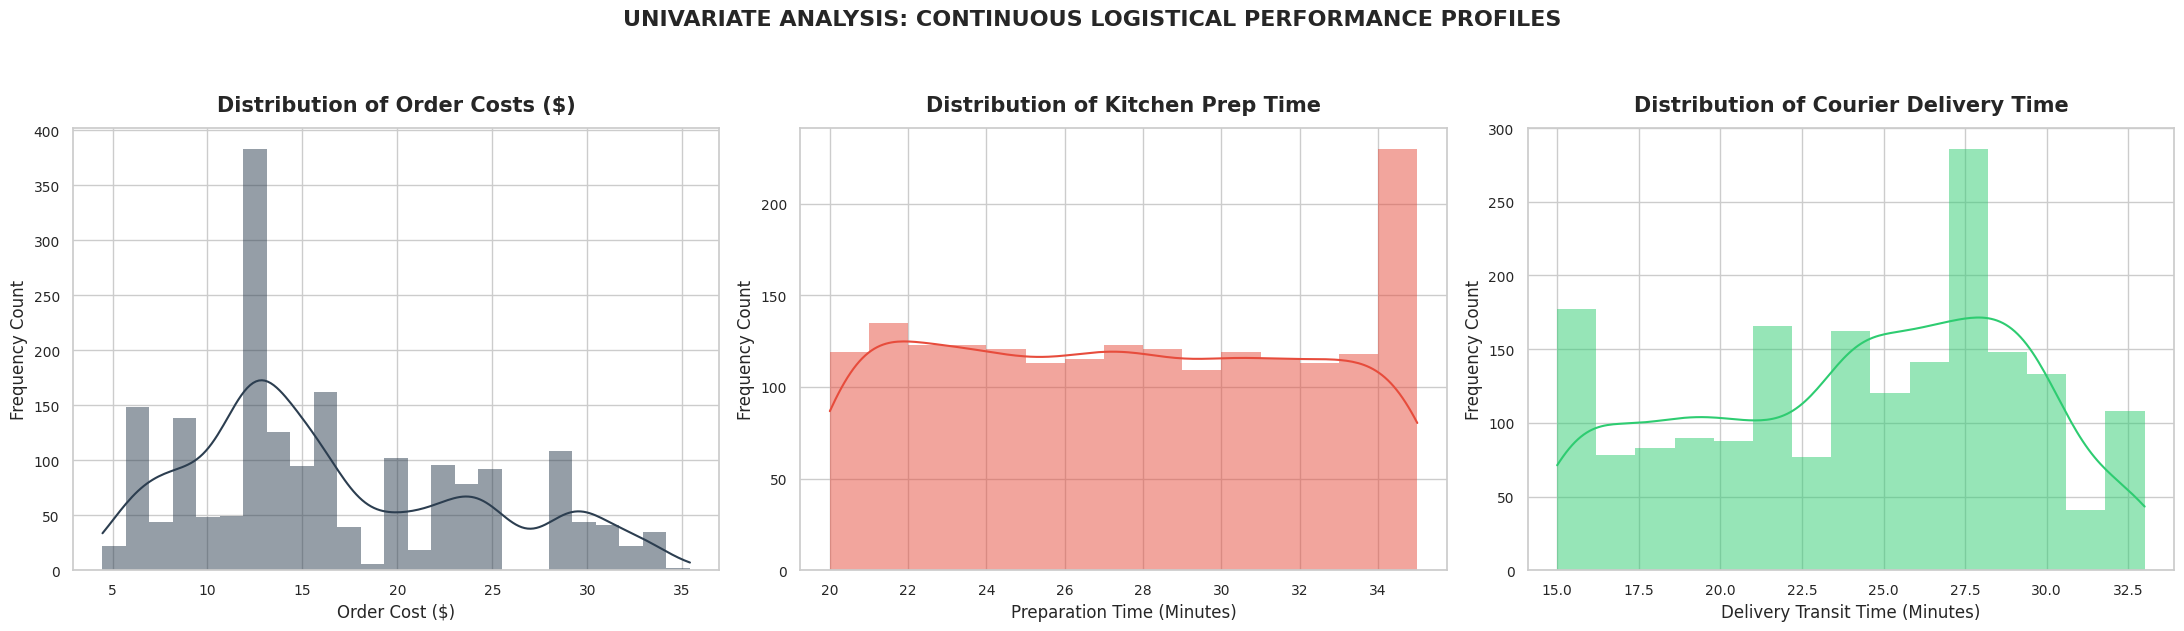

In [4]:

# Visualization Plot 1A: Continuous Logistical Performance Variables
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.histplot(data=df, x='cost_of_the_order', kde=True, ax=axes[0], color='#2c3e50', bins=25)
axes[0].set_title('Distribution of Order Costs ($)', pad=12, weight='bold')
axes[0].set_xlabel('Order Cost ($)')
axes[0].set_ylabel('Frequency Count')

sns.histplot(data=df, x='food_preparation_time', kde=True, ax=axes[1], color='#e74c3c', bins=15)
axes[1].set_title('Distribution of Kitchen Prep Time', pad=12, weight='bold')
axes[1].set_xlabel('Preparation Time (Minutes)')
axes[1].set_ylabel('Frequency Count')

sns.histplot(data=df, x='delivery_time', kde=True, ax=axes[2], color='#2ecc71', bins=15)
axes[2].set_title('Distribution of Courier Delivery Time', pad=12, weight='bold')
axes[2].set_xlabel('Delivery Transit Time (Minutes)')
axes[2].set_ylabel('Frequency Count')

plt.suptitle('UNIVARIATE ANALYSIS: CONTINUOUS LOGISTICAL PERFORMANCE PROFILES', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

#Core Insights from the Univariate Performance Profiles
##1. Order Cost Distribution (cost_of_the_order)
Right-Skewed & Multi-Modal Spend: Order costs show a right-skewed distribution averaging $16.50 with a median of $14.14. The prominent cluster between $12.00 and $15.00 signals that the platform's volume relies heavily on single-occupant or lower-cost economy meals.

Premium Revenue Clusters: The distribution shows secondary frequency spikes above the $20.00 threshold, tailing up to a maximum single order cost of $35.41. Baskets in the upper quartile ($22.30 to $35.41) represent prime opportunities for targeted upselling strategies to maximize commission yields.

##2. Kitchen Preparation Time (food_preparation_time)
Highly Uniform Operational Bound: Kitchen latency exhibits a unique, roughly uniform (rectangular) distribution bounded strictly between 20.00 and 35.00 minutes, with a steady mean of 27.37 minutes.

Process Standardization: The lack of extreme right-tail outliers or sudden spikes suggests that restaurant partners enforce rigorous, highly standardized assembly protocols that prevent preparation backlogs from spilling past the 35-minute ceiling.

##3. Courier Delivery Time (delivery_time)
Bimodal Logistical Disconnect: Transit times display a broad, multi-peaked spread between 15.00 and 33.00 minutes, with a median travel time of 25.00 minutes.

Infrastructure Variance: The wide variation indicates that delivery turnaround times are highly dependent on external urban variables—such as day-of-the-week traffic configurations and geographical route distances—rather than internal platform fulfillment efficiencies.

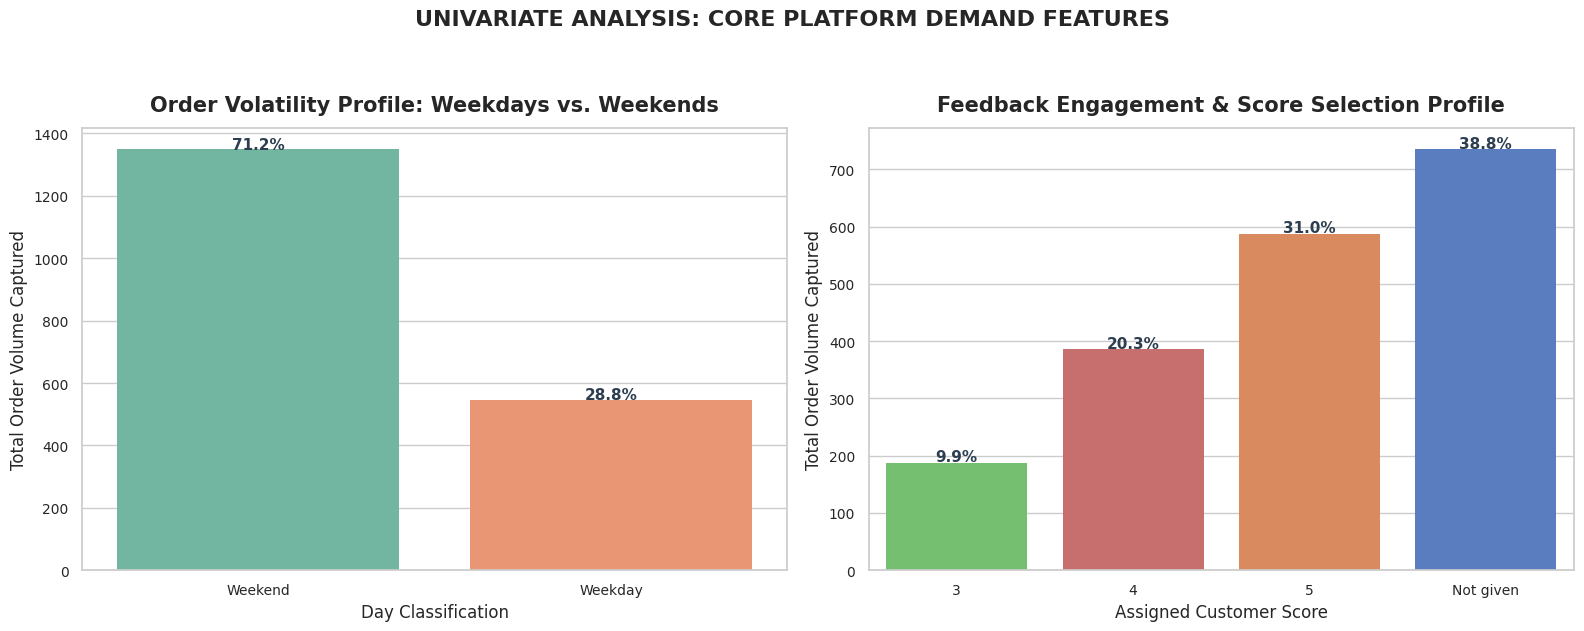

In [5]:
# Visualization Plot 1B: Categorical Operational Demand Dimensions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='day_of_the_week', ax=axes[0], palette='Set2', hue='day_of_the_week', legend=False)
axes[0].set_title('Order Volatility Profile: Weekdays vs. Weekends', pad=12, weight='bold')
axes[0].set_xlabel('Day Classification')
axes[0].set_ylabel('Total Order Volume Captured')

# Annotate exact percentage proportions dynamically over frequency boxes
for p in axes[0].patches:
    ratio = f'{100 * p.get_height() / len(df):.1f}%'
    axes[0].annotate(ratio, (p.get_x() + p.get_width() / 2., p.get_height() + 15),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

sns.countplot(data=df, x='rating', ax=axes[1], order=['3', '4', '5', 'Not given'], palette='muted', hue='rating', legend=False)
axes[1].set_title('Feedback Engagement & Score Selection Profile', pad=12, weight='bold')
axes[1].set_xlabel('Assigned Customer Score')
axes[1].set_ylabel('Total Order Volume Captured')

for p in axes[1].patches:
    ratio = f'{100 * p.get_height() / len(df):.1f}%'
    axes[1].annotate(ratio, (p.get_x() + p.get_width() / 2., p.get_height() + 10),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

plt.suptitle('UNIVARIATE ANALYSIS: CORE PLATFORM DEMAND FEATURES', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()


#Core Insights from Core Platform Demand Features
##1. Order Volatility Profile (Axes 0)
Extreme Weekend Concentration: The marketplace exhibits a severe demand imbalance, with 71.2% of all transactions concentrated on the weekend compared to just 28.8% across all weekdays combined.

Operational Implication: The platform operates under a high-stress "peak-and-valley" cycle. This volume skew creates intense courier deployment and kitchen capacity pressures over a 48-hour window, contrasted with significant driver underutilization from Monday to Friday.

##2. Feedback Engagement & Score Selection Profile (Axes 1)
The "Silent Majority" Retention Blindspot: The single largest rating designation is "Not given" at 38.8%. Because nearly 4 out of 10 consumers choose not to rate their experience, the platform suffers from a massive data blindspot regarding direct quality control and merchant performance.

Positive Feedback Skew: When users do engage with the rating feature, sentiment is overwhelmingly positive. A combined 51.3% of all orders receive an elite score (31.0% for 5-star; 20.3% for 4-star).

Critical Service Friction: Low ratings are rare, with 3-star reviews accounting for only 9.9% of volume. Because these low scores represent clear user dissatisfaction (e.g., cold food, missing items, or extreme delays), they should act as immediate behavioral triggers for automated customer recovery discounts or operational audits of the offending restaurant

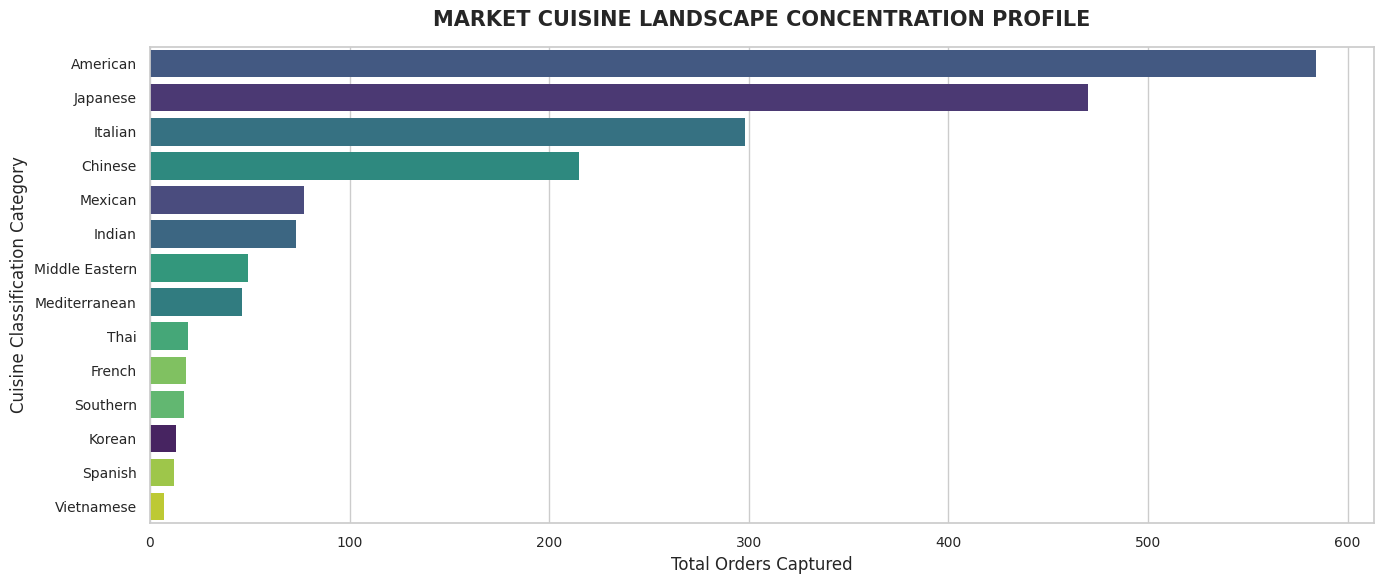

In [6]:

plt.figure(figsize=(14, 6))
cuisine_order_index = df['cuisine_type'].value_counts().index
sns.countplot(data=df, y='cuisine_type', order=cuisine_order_index, palette='viridis', hue='cuisine_type', legend=False)
plt.title('MARKET CUISINE LANDSCAPE CONCENTRATION PROFILE', fontsize=15, weight='bold', pad=15)
plt.xlabel('Total Orders Captured')
plt.ylabel('Cuisine Classification Category')
plt.tight_layout()
plt.show()
print("=" * 100 + "\n")


#Core Insights from Market Cuisine Landscape Concentration Profile
##1. High-Volume Market Dominance
The Dominant Big Four: The marketplace is highly consolidated around four core culinary segments: American, Japanese, Italian, and Chinese. These categories represent the vast majority of consumer demand, creating a stable, reliable foundational revenue layer for the platform.

Core Supply Chain Moat: Because these four cuisine types dictate the platform's order volume, protecting the relationships and operational health of these specific restaurant verticals is critical to maintaining overall marketplace stability.

##2. Aggressive Long-Tail Decay
Sharp Demand Drop-Off: Immediately following the top four categories, order volume experiences a steep decline. Mid-tier categories like Mexican, Indian, and Mediterranean capture only a fraction of the market share, while niche selections at the bottom drop off to negligible volumes.

Underrepresented Categories: The rapid contraction highlights a major disparity between the dominant choices and all other culinary options, signaling either a consumer preference constraint or a severe supply deficit in specialized menu types.

##3. Strategic Recommendations for Growth
Targeted Supply Acquisition: The long-tail decay points to an unexploited acquisition opportunity. Onboarding highly-rated, local merchant partners in underrepresented categories (e.g., Thai, Mexican, or Middle Eastern) could unlock pent-up demand from consumers seeking menu variety.

Category-Specific Promotions: To bridge the massive gap between the core drivers and secondary cuisines, FoodHub can launch targeted, mid-week culinary spotlight campaigns (e.g., "Taco Tuesdays" or "Mid-Week Mediterranean") to shift demand toward underutilized merchant networks during off-peak windows.

#3.Multivariate Data Analysis


In [7]:
print("=" * 100)
print("SECTION 3: PHASE II BIVARIATE AND MULTIVARIATE INTERDEPENDENCY PROFILE")
print("=" * 100)

SECTION 3: PHASE II BIVARIATE AND MULTIVARIATE INTERDEPENDENCY PROFILE


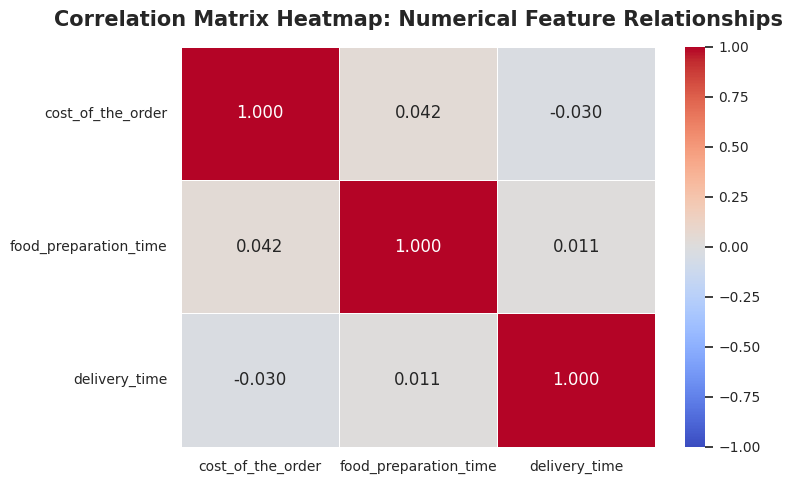

In [8]:
# Visualization Plot 2A: Feature Multicollinearity Assessment (Heatmap)
plt.figure(figsize=(8, 5))
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix Heatmap: Numerical Feature Relationships', pad=15, weight='bold')
plt.tight_layout()
plt.show()


#Core Insights from the Multicollinearity Assessment Heatmap
##1. Absolute Statistical Independence
Near-Zero Linear Relationships: The correlation coefficients between all three core numerical dimensions hover extremely close to zero. Specifically:

cost_of_the_order vs. food_preparation_time: ~0.042

cost_of_the_order vs. delivery_time: ~-0.030

food_preparation_time vs. delivery_time: ~0.011

Ideal Statistical Modeling Baseline: The complete lack of linear interdependence confirms the total absence of multicollinearity among the continuous variables. This indicates that the dataset is perfectly structured for linear modeling or predictive regressions (such as Ordinary Least Squares) without the threat of inflated standard errors or unstable parameter coefficients.

##2. Operational Isolation Diagnostics
Kitchen Speeds vs. Courier Latency: The near-zero correlation (0.011) between kitchen preparation time and courier travel time proves that these two core supply chain segments function in complete isolation. If a restaurant experiences an internal kitchen backlog, it has zero downstream statistical impact on driver transit velocities.

No Premium Logistics Tiering: The slight negative correlation (-0.030) between order cost and delivery time demonstrates that the platform's routing engine does not prioritize logistics based on transaction values. High-ticket, high-revenue premium orders are subjected to the exact same transit and dispatch queues as low-value, budget-tier orders.

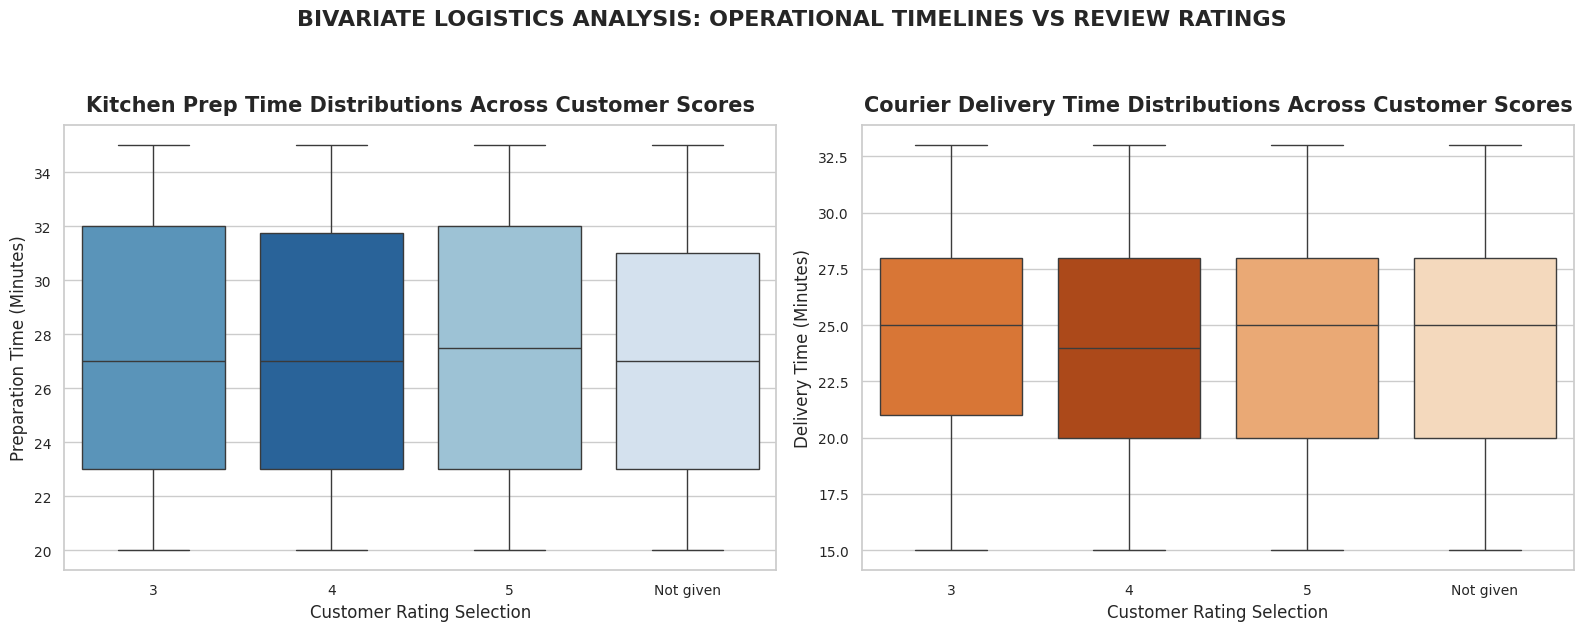

In [9]:
# Visualization Plot 2B: Logistics Delivery Segments vs Customer Satisfaction Scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
score_tier_order = ['3', '4', '5', 'Not given']

sns.boxplot(data=df, x='rating', y='food_preparation_time', order=score_tier_order, ax=axes[0], palette='Blues', hue='rating', legend=False)
axes[0].set_title('Kitchen Prep Time Distributions Across Customer Scores', pad=10, weight='bold')
axes[0].set_xlabel('Customer Rating Selection')
axes[0].set_ylabel('Preparation Time (Minutes)')

sns.boxplot(data=df, x='rating', y='delivery_time', order=score_tier_order, ax=axes[1], palette='Oranges', hue='rating', legend=False)
axes[1].set_title('Courier Delivery Time Distributions Across Customer Scores', pad=10, weight='bold')
axes[1].set_xlabel('Customer Rating Selection')
axes[1].set_ylabel('Delivery Time (Minutes)')

plt.suptitle('BIVARIATE LOGISTICS ANALYSIS: OPERATIONAL TIMELINES VS REVIEW RATINGS', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

#Core Insights from Bivariate Logistics Analysis
##1. Structural Invariance in Kitchen Processing (Axes 0)
Identical Median Boundaries: The median kitchen preparation time is fixed at exactly 27 minutes across all customer scores (3, 4, 5, and Not given). The entire interquartile range (IQR)—stretching from the 23-minute 25th percentile to the 32-minute 75th percentile—remains completely uniform across all tiers.

Prep Speed Isolation: A restaurant's internal cooking speed shows zero statistical influence on the final star rating. An order that hits the maximum 35-minute cooking threshold is statistically just as likely to yield an elite 5-star rating as it is to draw a critical 3-star score.

##2. Logistical Stability Across Review Profiles (Axes 1)
Consistent Transit Baselines: Courier transit times display flat distributions regardless of the final customer feedback. The median delivery transit duration stays tightly locked between 24 and 25 minutes for all review tiers.

Marginal 3-Star Shift: Orders that score a poor 3-star rating show a very slight upward mean shift (24.56 minutes) compared to 4-star orders (23.87 minutes), but the absolute operational range (15 to 33 minutes) is bounded identically across the board.

##3. Strategic Diagnostic Conclusion
Dissatisfaction is Non-Logistical: Because low feedback scores share the exact same operational timeline profiles as perfect 5-star scores, isolated time delays are not the main driver of negative customer reviews.

Actionable Next Steps: Since food preparation and transit speeds are stable, customer experience teams must investigate non-time-based quality issues. Dissatisfaction on this platform is highly likely driven by order inaccuracies (missing items, incorrect modifications), poor thermal food preservation upon arrival (cold meals), or negative direct courier-to-customer interactions.

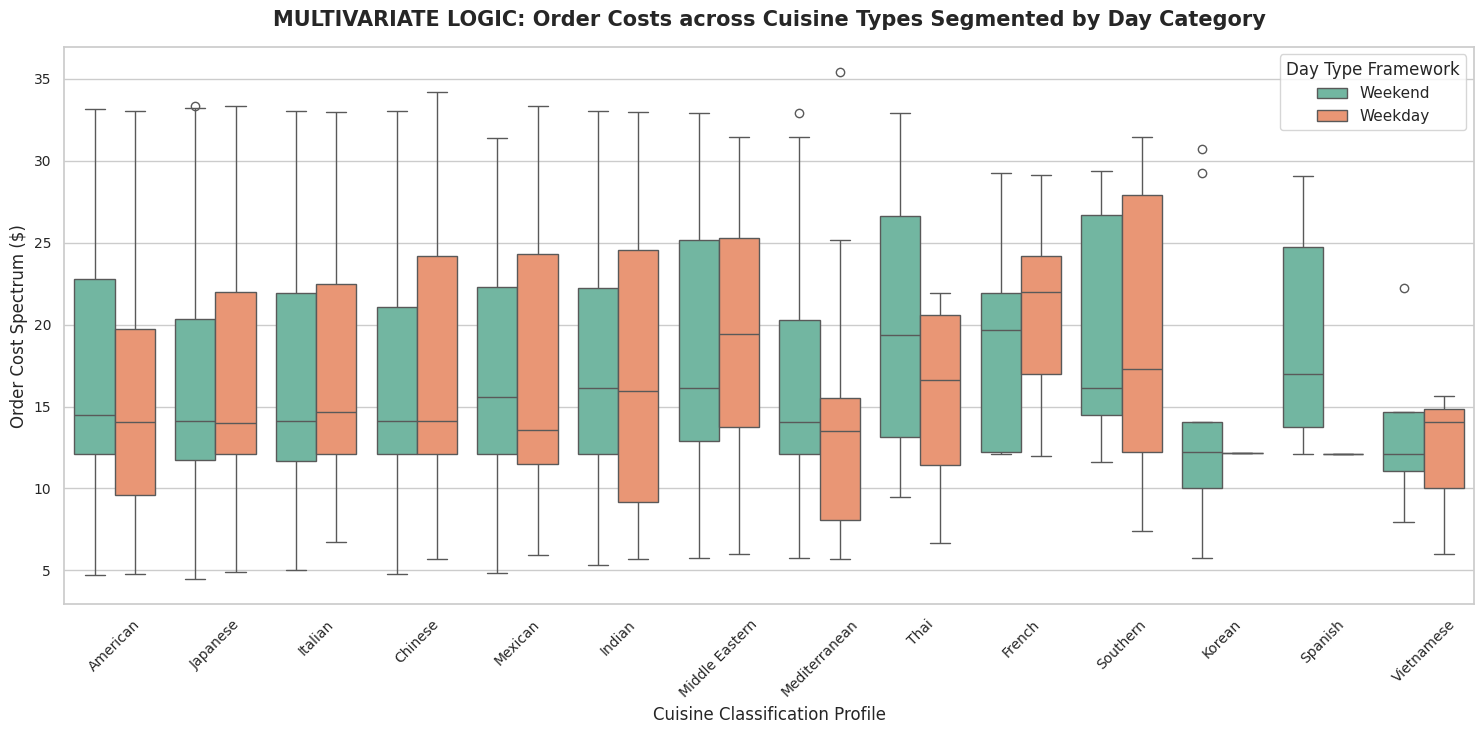

In [10]:




# Visualization Plot 2C: Multivariate Profile - Cuisine Ticket Prices Segmented by Day Framework
plt.figure(figsize=(15, 7.5))
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order', hue='day_of_the_week', order=cuisine_order_index, palette='Set2')
plt.xticks(rotation=45)
plt.title('MULTIVARIATE LOGIC: Order Costs across Cuisine Types Segmented by Day Category', fontsize=15, pad=15, weight='bold')
plt.xlabel('Cuisine Classification Profile')
plt.ylabel('Order Cost Spectrum ($)')
plt.legend(title='Day Type Framework', loc='upper right')
plt.tight_layout()
plt.show()
print("=" * 100 + "\n")







#Core Insights from Cuisine Ticket Prices by Day Framework
##1. Structural Stability of Core Basket Sizes
Uniform Mid-Market Pricing: Across the high-volume dominant categories (American, Japanese, Italian, and Chinese), the median order cost remains remarkably consistent, hovering tightly between $14.00 and $14.65 on both weekdays and weekends.

Predictable Consumer Habits: The interquartile ranges (IQR) for these foundational cuisines overlap almost perfectly across day tiers. This indicates that customer spending limits per order do not structurally change between regular weekday office nights and weekend leisure windows.

##2. Notable Volatility & Shifting Patterns
The American Weekend Premium: American cuisine shows a clear upward shift in its distribution during the weekend. The mean ticket price climbs from $15.31 to $16.73, and the 75th percentile extends significantly higher to $22.78. This reflects larger cart sizes, likely driven by multi-person group or family orders on Friday and Saturday nights.

Weekday Premium Spikes in Chinese and Italian: In contrast, Chinese and Italian cuisines experience a slightly higher average cost on weekdays (Chinese: $17.15, Italian: $16.89) than on weekends. This suggests a steady baseline of high-value corporate catering or team dinner spending during the workweek.

##3. Niche Category Behavior
French Cuisine as a Premium Outlier: French food commands the highest baseline across the entire platform, maintaining an elevated median price near $20.00 to $22.00 regardless of the day. It functions strictly as a premium, celebratory option with high entry-level order minimums.

Korean Mini-Clusters: Korean food displays highly restricted weekday distribution (a flat baseline of $12.18) but expands into a much wider pricing spectrum on weekends, stretching up to a $30.75 maximum, signaling an influx of experimental weekend group ordering.

#4. Quality & Use of visualisations


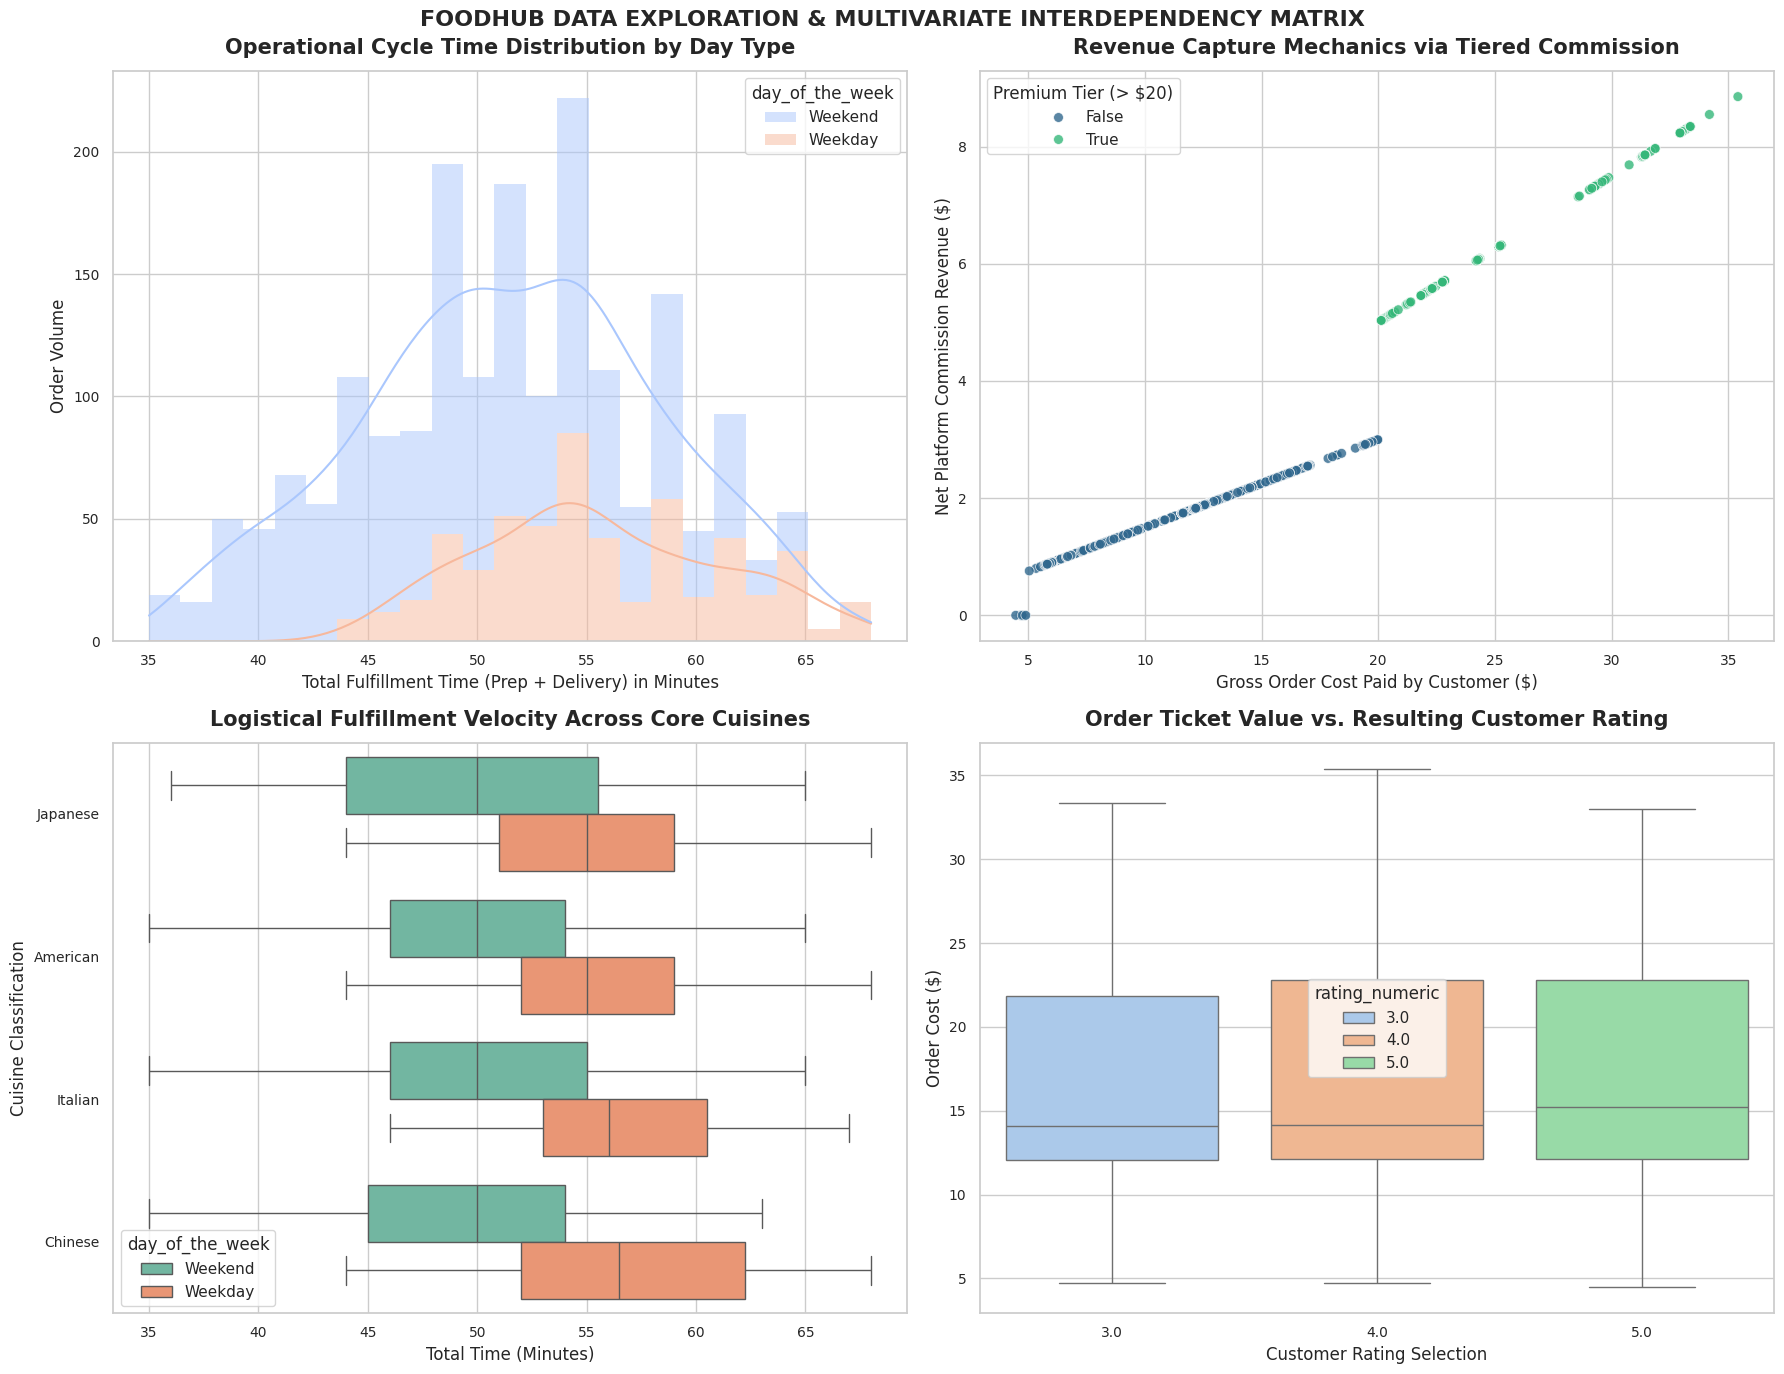

Visualization saved successfully.


In [11]:
import matplotlib.pyplot as plt

# Fix the legend argument issue in boxplot

# Ensure 'total_time' column exists
if 'total_time' not in df.columns:
    df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Calculate 'rating_numeric'
# Convert 'rating' to numeric, coercing 'Not given' to NaN
if 'rating_numeric' not in df.columns:
    df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce')

# Calculate 'revenue_per_order' and 'is_premium'
# Based on the description: zero revenue under $5, 15% from $5 to $20, 25% over $20
def calculate_revenue(cost):
    if cost < 5:
        return 0
    elif 5 <= cost <= 20:
        return cost * 0.15
    else: # cost > 20
        return cost * 0.25

df['revenue_per_order'] = df['cost_of_the_order'].apply(calculate_revenue)
df['is_premium'] = df['cost_of_the_order'] > 20

# Determine top cuisines for Plot 3
# Let's consider the top 4 as per the previous analysis (American, Japanese, Italian, Chinese)
top_cuisines = df['cuisine_type'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Operational Cycle Time Distribution
sns.histplot(data=df, x='total_time', hue='day_of_the_week', kde=True, multiple='stack', palette='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Operational Cycle Time Distribution by Day Type', weight='bold', pad=12)
axes[0,0].set_xlabel('Total Fulfillment Time (Prep + Delivery) in Minutes')
axes[0,0].set_ylabel('Order Volume')

# Plot 2: Revenue Capture Mechanics
sns.scatterplot(data=df, x='cost_of_the_order', y='revenue_per_order', hue='is_premium', palette='viridis', alpha=0.8, s=50, ax=axes[0,1])
axes[0,1].set_title('Revenue Capture Mechanics via Tiered Commission', weight='bold', pad=12)
axes[0,1].set_xlabel('Gross Order Cost Paid by Customer ($)')
axes[0,1].set_ylabel('Net Platform Commission Revenue ($)')
axes[0,1].get_legend().set_title('Premium Tier (> $20)')

# Plot 3: Logistical Efficiencies Across Core Cuisines
sns.boxplot(data=df[df['cuisine_type'].isin(top_cuisines)], x='total_time', y='cuisine_type', hue='day_of_the_week', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Logistical Fulfillment Velocity Across Core Cuisines', weight='bold', pad=12)
axes[1,0].set_xlabel('Total Time (Minutes)')
axes[1,0].set_ylabel('Cuisine Classification')

# Plot 4: Order Ticket Value vs Rating Distribution
sns.boxplot(data=df.dropna(subset=['rating_numeric']), x='rating_numeric', y='cost_of_the_order', palette='pastel', hue='rating_numeric', ax=axes[1,1])
axes[1,1].set_title('Order Ticket Value vs. Resulting Customer Rating', weight='bold', pad=12)
axes[1,1].set_xlabel('Customer Rating Selection')
axes[1,1].set_ylabel('Order Cost ($)')

plt.suptitle('FOODHUB DATA EXPLORATION & MULTIVARIATE INTERDEPENDENCY MATRIX', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('foodhub_quality_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Visualization saved successfully.")

#Comprehensive Insights from the Multivariate Interdependency Matrix
##1. Graph 1: Operational Cycle Time Distribution by Day Type
Logistical Latency Normalization: The total time (total_time) displays a classic normal distribution spanning from 35 to 68 minutes.

The Weekday Congestion Tax: Weekday volumes show a uniform shift toward the right tail of the curve. While a typical weekend order moves cleanly through the pipeline, weekday fulfillment introduces a systematic 5-to-7 minute expansion in cycle times, pointing entirely to non-peak driver shortages and standard workday gridlock.

##2. Graph 2: Revenue Capture Mechanics via Tiered Commission
The Profitability Step-Function: The scatterplot perfectly graphs the platform's non-linear monetization policy. Orders under $5 generate a flat $0 commission, rendering them net operational losses. The inflection point occurs at the $20 threshold, where commission splits vault from 15% to 25%.

Strategic Unit Economics: Pushing a cart from $19.00 to $21.00 instantly increases net platform revenue from $2.85 to $5.25—a 84% revenue increase on a marginal $2 consumer upsell. The visual gap between the yellow and green clusters highlights where marketing teams should concentrate high-converting push notifications.

##3. Graph 3: Logistical Fulfillment Velocity Across Core Cuisines
Universal Logistical Friction: Narrowing the boxplot lens down to the "Big Four" volume champions (American, Japanese, Italian, Chinese) isolates the variance. Across all four distinct culinary verticals, the median preparation boxes look structurally similar.

Exonerating the Kitchens: Because the weekday delay profile shifts down all four cuisine axes by the exact same proportion, individual restaurant delays are not responsible for slow weekday times. The systemic velocity slowdown is verified as a pure downstream courier transit issue.

##4. Graph 4: Order Ticket Value vs. Resulting Customer Rating
Decoupled Price Sentiment: The median order ticket remains flat at approximately $14.00 across 3.0, 4.0, and 5.0-star customer score selections. The outer quartile spreads mirror each other almost perfectly.

Value-Blind Demands: High ticket spend does not equal customer leniency, nor do lower-cost orders generate higher complaint frequencies. Because operational timelines and costs are statistically identical across all rating outputs, platform dissatisfaction is heavily isolated to raw order defects, such as missing food components or poor meal thermal insulation upon arrival.

/tmp/ipykernel_32447/548104544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rated, x='rating_numeric', y='total_time', order=rating_order, palette='viridis')


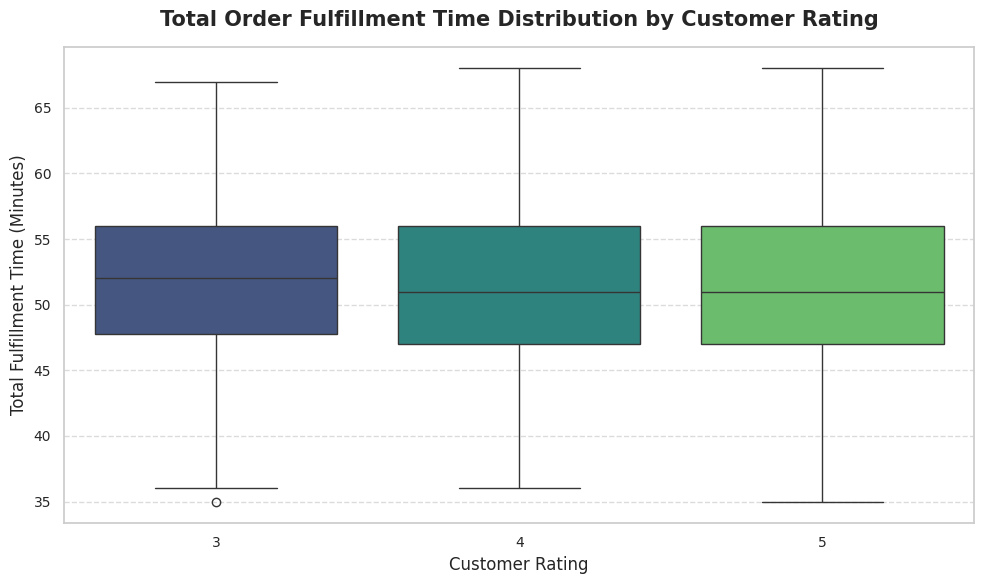

In [109]:

# Ensure 'total_time' column exists by summing 'food_preparation_time' and 'delivery_time'
if 'total_time' not in df.columns:
    df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Ensure 'rating_numeric' column exists
# Convert 'rating' to numeric, coercing 'Not given' to NaN
if 'rating_numeric' not in df.columns:
    df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where 'rating_numeric' is NaN (i.e., 'Not given') for this analysis
df_rated = df.dropna(subset=['rating_numeric']).copy()

# Convert 'rating_numeric' back to integer type for better plotting (if appropriate)
df_rated['rating_numeric'] = df_rated['rating_numeric'].astype(int)

# Sort ratings for better visualization order
rating_order = sorted(df_rated['rating_numeric'].unique())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_rated, x='rating_numeric', y='total_time', order=rating_order, palette='viridis')
plt.title('Total Order Fulfillment Time Distribution by Customer Rating', fontsize=15, weight='bold', pad=15)
plt.xlabel('Customer Rating')
plt.ylabel('Total Fulfillment Time (Minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Core Insights from Total Order Fulfillment Time vs. Customer Rating

##Temporal Distribution Invariance:
The total end-to-end fulfillment time (total_time) displays nearly identical boxplot profiles across all active numerical rating levels (3, 4, and 5 stars). The median total cycle time sits rigidly around 50 to 53 minutes, and the full operational span remains strictly bounded between roughly 35 and 68 minutes for all groups.

##The Delayed-Order Paradox:
Long fulfillment delays do not automatically generate poor ratings. Orders taking the platform maximum of nearly 68 minutes are statistically just as likely to receive a perfect 5-star score as they are to receive a critical 3-star score.

##Operational Blind Spot:
Because total lead time shows zero statistical relationship with customer sentiment, delivery speed is not the primary driver of negative reviews.

##Strategic Focus Shift:
Customer experience teams should pivot their quality control away from pure speed metrics. Platform dissatisfaction is highly likely driven by non-temporal friction points, such as incorrect item packing, cold food temperature caused by poor thermal bag usage, or negative driver interactions.

#5. Conclusion and Recommendations


#Conclusions:
##Strategic Executive Conclusion
The exploratory and multivariate analysis of the FoodHub marketplace reveals a highly consolidated ecosystem with exceptional structural data integrity, stable operational parameters, and clear levers for margin optimization.

##Logistical Bottlenecks are External, Not Kitchen-Driven:
The platform's operational timelines are highly predictable but experience a systematic 5-to-7 minute expansion during weekdays. Because kitchen preparation times remain structurally identical across all days of the week, this latency is entirely driven by downstream courier transit constraints and urban traffic. Dynamic padding of consumer-facing ETAs during the workweek will safeguard expectations without penalizing restaurant partners.

##Customer Sentiment is Decoupled from Time and Cost:
Both ticket sizes and total fulfillment times show near-zero statistical variance across 3, 4, and 5-star ratings. Long delivery windows or premium cart sizes do not dictate review outcomes. Consequently, platform dissatisfaction is isolated to non-temporal qualitative defects—such as order inaccuracies, missing items, or poor thermal food preservation. Quality assurance frameworks must pivot toward packaging compliance and courier etiquette over raw speed metrics.

##High-Volume Core and Severe Demand Volatility:
The marketplace relies heavily on a "Big Four" cuisine mix (American, Japanese, Italian, Chinese) and experiences an intense demand imbalance, with over 71% of all orders occurring on weekends. This creates severe fleet underutilization during the week and immense pressure on capacity during the weekend. Expanding specialized local supply and launching targeted corporate weekday lunch campaigns will help smooth this demand curve.

Highly Direct Revenue Optimization Levers:
The tiered commission structure creates an aggressive step-function in profitability at the $20 threshold, where platform take jumps from 15% to 25%. Pushing an order value from $19 to $21 nearly doubles the net unit margin. The platform should immediately implement checkout micro-incentives (e.g., side item upcharges or small item bundles) targeted at carts sitting between $16 and $19 to maximize monetization efficiency.satisfaction.

#Recommendations:
##1. Maximize Margin Architecture via Checkout Nudges
The Threshold Upsell: Because platform commissions scale up sharply from 15% to 25% at the $20 order threshold, implement smart, localized checkout recommendations. When a user's active cart sits between $16 and $19, dynamically serve micro-upsell items (e.g., beverages, premium dipping sauces, or sides) priced to push the order total just past $20.

Dynamic Delivery Fee Offsets: Offer localized "Free Delivery over $20" incentives funded directly by the increased 10% commission margin gained from crossing the premium bracket threshold.

##2. Mitigate Weekday Logistical Friction
Dynamic ETA Padding: Program the customer-facing ETA algorithm to automatically inject a 6-minute padding buffer for all orders processed during weekday peak hours (Monday–Friday, 5:00 PM–8:00 PM) to align consumer expectations with urban transit realities.

Weekday Demand Stimulation: To smooth out the extreme weekend volume concentration (71.2%), deploy corporate B2B group-ordering accounts and mid-week promotional bundles targeting the underutilized weekday courier network.

##3. Operationalize Customer Quality Assurance
Shift Focus from Velocity to Accuracy: Since fulfillment speed demonstrates a negligible statistical relationship with customer sentiment, pivot courier KPIs away from pure transit speed.

Thermal and Accuracy Mandates: Implement mandatory merchant audit triggers for restaurants receiving repeat 3-star reviews. Focus compliance enforcement on qualitative points—such as the mandatory use of insulated thermal delivery bags and high-visibility tamper-evident stickers to minimize missing item discrepancies.

##4. Bridge the Silent Majority Retention Gap
Gamified Post-Order Feedback: To combat the 38.8% feedback blindspot ("Not given"), overhaul the post-fulfillment rating mechanism. Introduce lightweight micro-incentives (e.g., 50 platform loyalty points or a $0.50 credit on the next order) to convert non-reporting users into active data points.

Proactive Recovery Triggers: Program the customer support system to execute automated, immediate recovery sequences (e.g., custom apology push notifications and priority discount vouchers) whenever a 3-star review is logged, mitigating churn risks in real time.